#### ARIMA , SARIMA , SARIMAX MODELS

In [1]:
!pip install pmdarima


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [48]:
## Libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import month_plot , quarter_plot, plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from pmdarima import ARIMA, AutoARIMA , model_selection, auto_arima
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from sklearn.model_selection import ParameterGrid

In [3]:
## load the data
df = pd.read_csv(r"C:\Users\manoj.c\Downloads\time-series-analysis\Time Series Analysis\ARIMA, SARIMA and SARIMAX\daily_revenue.csv", index_col="date", parse_dates=True, dayfirst=True)
df.head()

,revenue,discount_rate,coupon_rate
date,,,
2018-01-01,"6,270,839",34.27%,1.09%
2018-01-02,"8,922,076",30.87%,1.08%
2018-01-03,"8,446,101",28.11%,1.01%
2018-01-04,"7,785,798",27.32%,0.96%
2018-01-05,"6,375,303",25.70%,0.90%


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1795 entries, 2018-01-01 to 2022-11-30
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   revenue        1795 non-null   object
 1   discount_rate  1795 non-null   object
 2   coupon_rate    1795 non-null   object
dtypes: object(3)
memory usage: 56.1+ KB


In [5]:
# transform revenue into a float
df['revenue'] = df['revenue'].str.replace(",","").astype(float)
df.tail()

,revenue,discount_rate,coupon_rate
date,,,
2022-11-26,26934947.0,30.41%,0.38%
2022-11-27,31890868.0,29.75%,0.35%
2022-11-28,32100918.0,25.27%,8.93%
2022-11-29,14314613.0,19.54%,0.26%
2022-11-30,15026662.0,17.10%,0.32%


In [6]:
# setting the frequency
df = df.asfreq('D')

In [7]:
# Change the time series variable name
df = df.rename(columns={'revenue' : 'y'})
df.head()

,y,discount_rate,coupon_rate
date,,,
2018-01-01,6270839.0,34.27%,1.09%
2018-01-02,8922076.0,30.87%,1.08%
2018-01-03,8446101.0,28.11%,1.01%
2018-01-04,7785798.0,27.32%,0.96%
2018-01-05,6375303.0,25.70%,0.90%


#### Exploratory Data Analysis

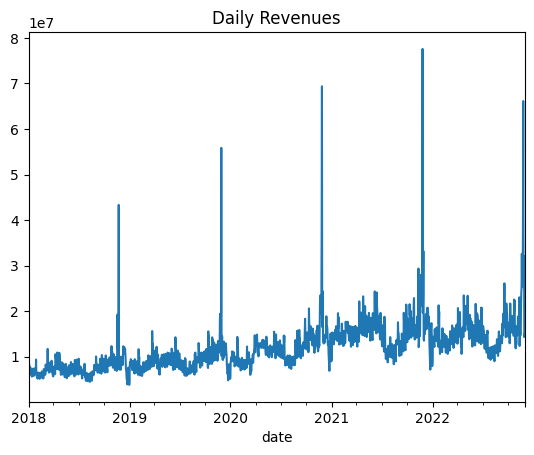

In [8]:
df['y'].plot(title="Daily Revenues")
plt.show()

C:\Users\manoj.c\AppData\Local\Temp\ipykernel_22068\2938119753.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  month_plot(df['y'].resample('M').mean(),  ylabel = "Monthly wise Revenues")


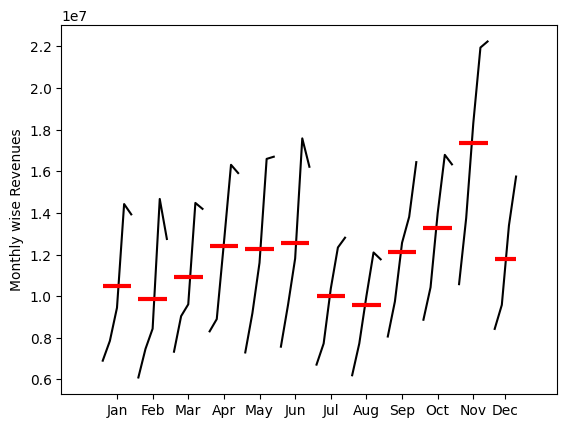

In [9]:
# Plotting the monthly seasonality
month_plot(df['y'].resample('M').mean(),  ylabel = "Monthly wise Revenues")
plt.show()

C:\Users\manoj.c\AppData\Local\Temp\ipykernel_22068\3275070843.py:1: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  quarter_plot(df['y'].resample('Q').mean(), ylabel="Quarterly wise Revenues")


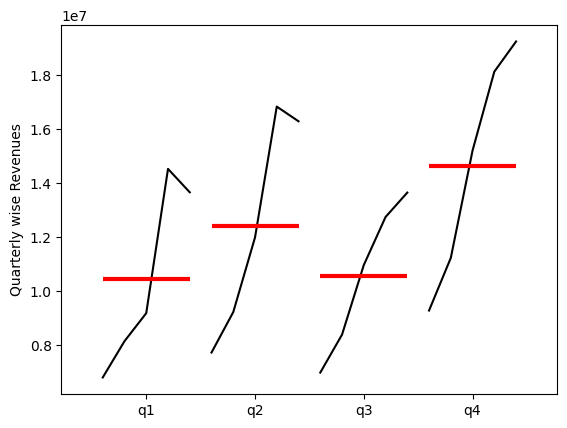

In [10]:
quarter_plot(df['y'].resample('Q').mean(), ylabel="Quarterly wise Revenues")
plt.show()

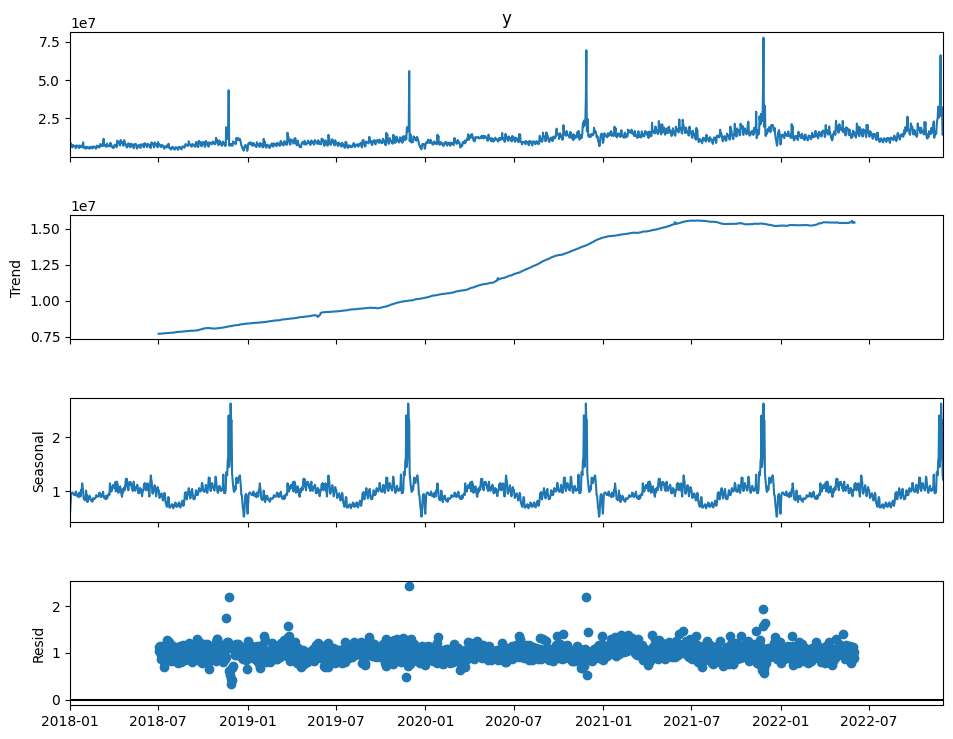

In [11]:
decomposition = seasonal_decompose(df['y'],model='mul',period=365)
fig = decomposition.plot()
fig.set_size_inches(10,8)
plt.show()

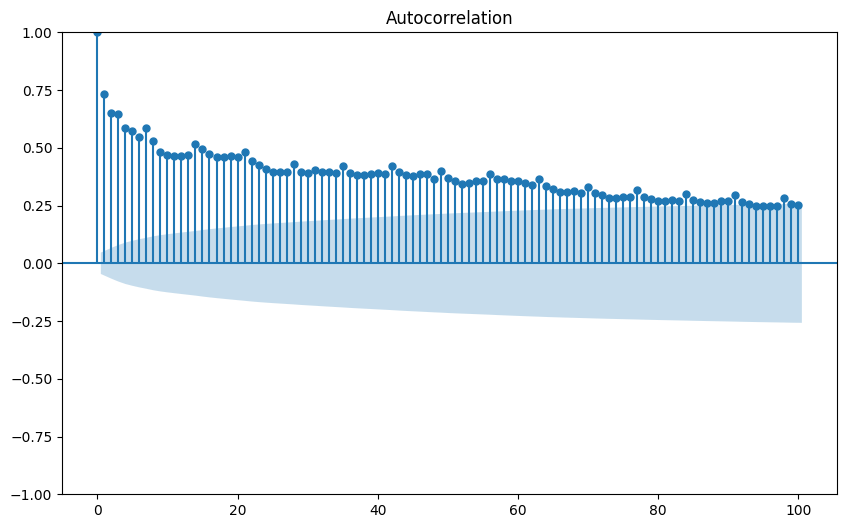

In [12]:
## ACF
fig , ax = plt.subplots(figsize = (10,6))
plot_acf(df['y'],lags=100, ax=ax)
plt.show()

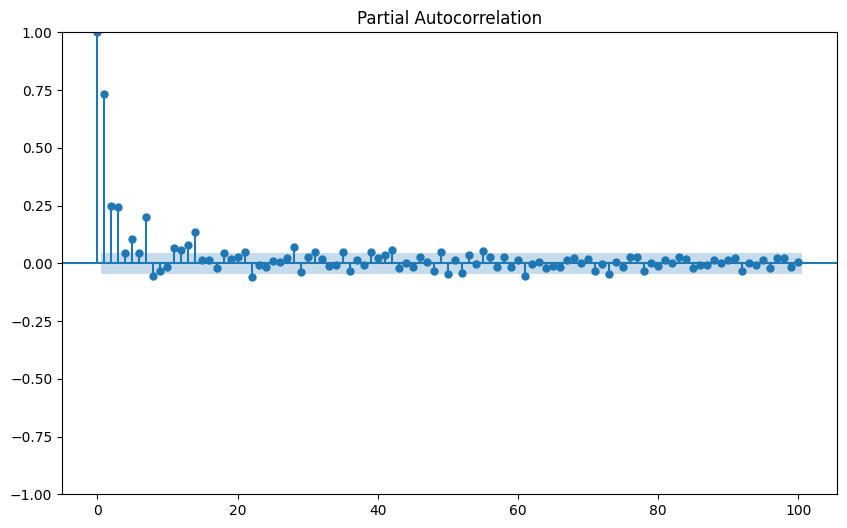

In [13]:
## PACF
fig, ax = plt.subplots(figsize = (10,6))
plot_pacf(df['y'], lags=100, ax=ax)
plt.show()

* **ARIMA**:

  * **Stands for**: AutoRegressive Integrated Moving Average
  * **Why use ARIMA**:

    * User-friendly
    * Easy to implement
    * Accurate predictions
  * **Note**: ARIMA requires additional help to handle seasonality.

* **SARIMA**:

  * **Stands for**: Seasonal AutoRegressive Integrated Moving Average
  * **Why SARIMA**:

    * An upgraded version of ARIMA
    * Specifically designed to handle seasonality


##### ARIMA MODEL

In [14]:
## Split the Data into training and test
test_days = 30 
train, test = df.iloc[:-test_days, : ],df.iloc[-test_days: , :]
test

,y,discount_rate,coupon_rate
date,,,
2022-11-01,16703680.0,23.85%,1.50%
2022-11-02,15827022.0,20.76%,0.94%
2022-11-03,16154319.0,21.85%,0.92%
2022-11-04,14707212.0,20.17%,0.88%
2022-11-05,14877530.0,17.85%,0.41%
2022-11-06,18835528.0,16.40%,0.31%
2022-11-07,16094516.0,17.11%,0.30%
2022-11-08,15589508.0,16.64%,0.29%
2022-11-09,16608320.0,18.72%,0.74%


In [15]:
## Using pmdarima for the arima model & the best parameters
model = auto_arima(train['y'], seasonal=False)
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 1765
Model:               SARIMAX(5, 1, 2)   Log Likelihood              -28817.267
Date:                Wed, 10 Dec 2025   AIC                          57650.535
Time:                        09:57:42   BIC                          57694.337
Sample:                    01-01-2018   HQIC                         57666.720
                         - 10-31-2022                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4136      0.120     -3.449      0.001      -0.649      -0.179
ar.L2          0.3017      0.053      5.671      0.000       0.197       0.406
ar.L3          0.1570      0.028      5.705      0.000       0.103       0.211
ar.L4          0.0679      0.029      2.365      0.018       0.012       0.124
ar.L5          0.0466      0.024      1.937      0.053      -0.001       0.094
ma.L1         -0.1598      0.118     -1.354      0.176      -0.391       0.071
ma.L2         -0.7423      0.108     -6.872      0.000      -0.954      -0.531
sigma2      9.084e+12   1.86e-14   4.88e+26      0.000    9.08e+12    9.08e+12
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):            580903.26
Prob(Q):                              0.97   Prob(JB):                         0.00
Heteroskedasticity (H):               3.04   Skew:                             5.15
Prob(H) (two-sided):                  0.00   Kurtosis:                        91.30
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 1.23e+42. Standard errors may be unstable.
"""

In [16]:
## Predictions
predictions_arima = model.predict(n_periods = (len(test)))
predictions_arima

2022-11-01    1.445299e+07
2022-11-02    1.474103e+07
2022-11-03    1.503283e+07
2022-11-04    1.527520e+07
2022-11-05    1.534078e+07
2022-11-06    1.553442e+07
2022-11-07    1.554542e+07
2022-11-08    1.563967e+07
2022-11-09    1.565016e+07
2022-11-10    1.569221e+07
2022-11-11    1.570256e+07
2022-11-12    1.571953e+07
2022-11-13    1.572734e+07
2022-11-14    1.573420e+07
2022-11-15    1.573904e+07
2022-11-16    1.574197e+07
2022-11-17    1.574462e+07
2022-11-18    1.574600e+07
2022-11-19    1.574734e+07
2022-11-20    1.574804e+07
2022-11-21    1.574869e+07
2022-11-22    1.574906e+07
2022-11-23    1.574937e+07
2022-11-24    1.574956e+07
2022-11-25    1.574971e+07
2022-11-26    1.574981e+07
2022-11-27    1.574988e+07
2022-11-28    1.574994e+07
2022-11-29    1.574997e+07
2022-11-30    1.575000e+07
Freq: D, dtype: float64

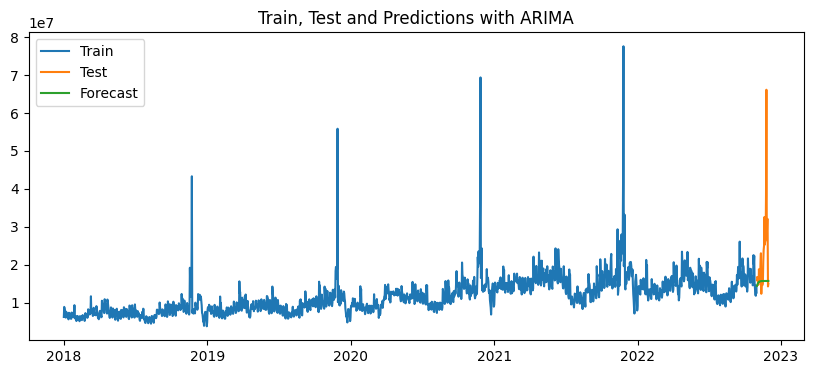

The MAE is  7267306.02
The RMSE is  12366038.30
The MAPE is 24.15 %


In [17]:
def model_assessment(train, test, predictions_arima, chart_title):
    # plot training, test and forecasts
    plt.figure(figsize=(10,4))
    plt.plot(train, label='Train')
    plt.plot(test,label="Test")
    plt.plot(predictions_arima, label = "Forecast")
    plt.legend()
    plt.title(f"Train, Test and Predictions with {chart_title}")
    plt.show()

    mae = mean_absolute_error(test,predictions_arima)
    mse = mean_squared_error(test,predictions_arima)
    rmse = np.sqrt(mse)  #convert MSE -> RMSE
    mape = mean_absolute_percentage_error(test,predictions_arima)
    print(f"The MAE is {mae: .2f}")
    print(f"The RMSE is {rmse: .2f}")
    print(f"The MAPE is {100 * mape:.2f} %")

model_assessment(train['y'],test['y'],predictions_arima,"ARIMA")

In [18]:
print(test.head())
print(predictions_arima.head())
print(test.dtypes)
print(predictions_arima.dtypes)


                     y discount_rate coupon_rate
date                                            
2022-11-01  16703680.0        23.85%       1.50%
2022-11-02  15827022.0        20.76%       0.94%
2022-11-03  16154319.0        21.85%       0.92%
2022-11-04  14707212.0        20.17%       0.88%
2022-11-05  14877530.0        17.85%       0.41%
2022-11-01    1.445299e+07
2022-11-02    1.474103e+07
2022-11-03    1.503283e+07
2022-11-04    1.527520e+07
2022-11-05    1.534078e+07
Freq: D, dtype: float64
y                float64
discount_rate     object
coupon_rate       object
dtype: object
float64


#### Stationarity
- Constant mean, variance, covariance over time.
- Stable patterns; easy to predict/model.
#### Differencing
- Subtract consecutive values to remove trends.
- Makes non-stationary data stationary.
#### ARIMA 'I' Component
- Determines differencing order (d).
- Applied until series is stationary.
#### 4 Non-Stationary Types
- **Trend**: Growing/changing mean → 1st differencing.
- **Changing Variance**: Varying amplitudes → log transform + differencing.
- **Changing Cycles**: Irregular lengths → seasonal differencing.
- **Stationary**: Stable; no differencing needed.
#### ADF Test
- Tests for unit root (non-stationarity).
- Reject null if p < 0.05.

#### Stationarity

In [19]:
from statsmodels.tsa.stattools import adfuller

# Run ADF test
result = adfuller(df['y'].dropna())

print("ADF Statistic:", result[0])
print("p-value:", result[1])
print("Number of Lags Used:", result[2])
print("Number of Observations:", result[3])
print("Critical Values:")
for key, value in result[4].items():
    print(f"   {key}: {value}")


ADF Statistic: -2.5583995323513893
p-value: 0.10190360862386194
Number of Lags Used: 21
Number of Observations: 1773
Critical Values:
   1%: -3.4340436225819664
   5%: -2.8631715289228103
   10%: -2.567638575476797


In [20]:
# Interpretation
p_value = result[1]
adf_stat = result[0]
crit_vals = result[4]

print("\n---- Interpretation ----")

if p_value < 0.05:
    print("📉 p-value < 0.05: Reject the null hypothesis.")
    print("➡️ The series IS stationary (no unit root).")
else:
    print("📈 p-value ≥ 0.05: Fail to reject the null hypothesis.")
    print("➡️ The series is NOT stationary (unit root present).")

# Additional interpretation using critical values
if adf_stat < crit_vals['5%']:
    print("📉 ADF statistic < 5% critical value:")
    print("➡️ Strong evidence of stationarity.")
else:
    print("📈 ADF statistic ≥ 5% critical value:")
    print("➡️ The series likely non-stationary.")



---- Interpretation ----
📈 p-value ≥ 0.05: Fail to reject the null hypothesis.
➡️ The series is NOT stationary (unit root present).
📈 ADF statistic ≥ 5% critical value:
➡️ The series likely non-stationary.


ADF Statistic (original): -2.5583995323513893
p-value (original): 0.10190360862386194

ADF Statistic (differenced): -12.808786916716002
p-value (differenced): 6.513792026816299e-24


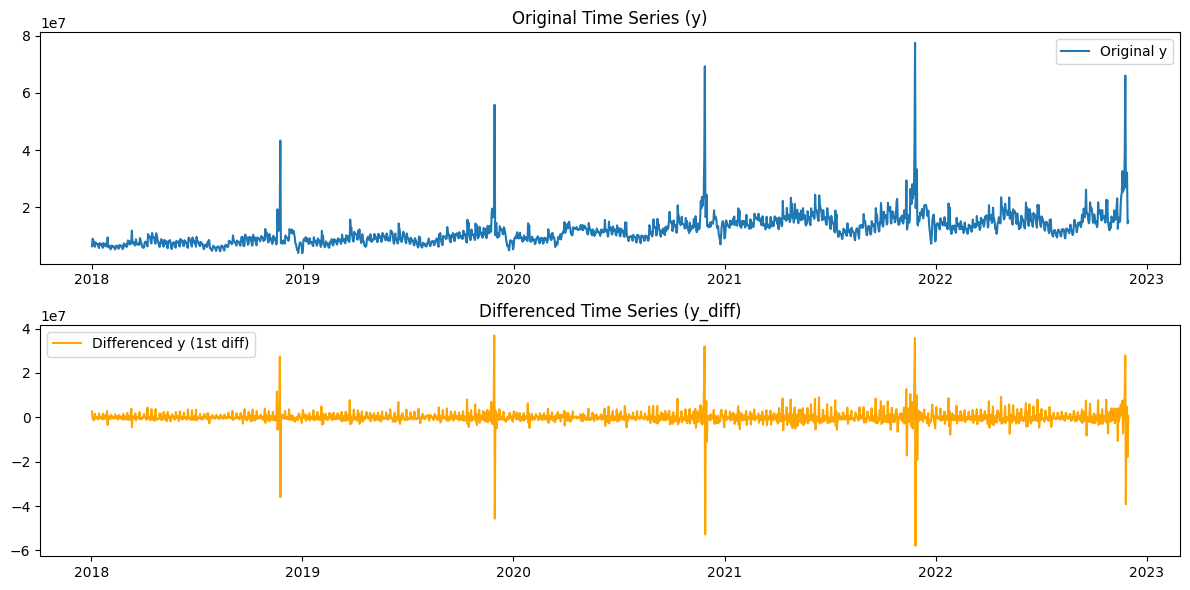

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller

# --- Assume df is your DataFrame and df["y"] is the time series ---

# 1. RUN ADF TEST ON ORIGINAL SERIES
result = adfuller(df['y'].dropna())
print("ADF Statistic (original):", result[0])
print("p-value (original):", result[1])

# 2. DIFFERENCE THE SERIES
df['y_diff'] = df['y'].diff()

# 3. RUN ADF TEST ON DIFFERENCED SERIES
result_diff = adfuller(df['y_diff'].dropna())
print("\nADF Statistic (differenced):", result_diff[0])
print("p-value (differenced):", result_diff[1])

# 4. PLOT ORIGINAL AND DIFFERENCED SERIES
plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)
plt.plot(df['y'], label='Original y')
plt.title('Original Time Series (y)')
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(df['y_diff'], label='Differenced y (1st diff)', color='orange')
plt.title('Differenced Time Series (y_diff)')
plt.legend()

plt.tight_layout()
plt.show()


In [22]:
from statsmodels.tsa.stattools import adfuller

# Run ADF test
result = adfuller(df['y_diff'].dropna())

print("ADF Statistic:", result[0])
print("p-value:", result[1])
print("Number of Lags Used:", result[2])
print("Number of Observations:", result[3])
print("Critical Values:")
for key, value in result[4].items():
    print(f"   {key}: {value}")

# Interpretation
p_value = result[1]
adf_stat = result[0]
crit_vals = result[4]

print("\n---- Interpretation ----")

if p_value < 0.05:
    print("📉 p-value < 0.05: Reject the null hypothesis.")
    print("➡️ The series IS stationary (no unit root).")
else:
    print("📈 p-value ≥ 0.05: Fail to reject the null hypothesis.")
    print("➡️ The series is NOT stationary (unit root present).")

# Additional interpretation using critical values
if adf_stat < crit_vals['5%']:
    print("📉 ADF statistic < 5% critical value:")
    print("➡️ Strong evidence of stationarity.")
else:
    print("📈 ADF statistic ≥ 5% critical value:")
    print("➡️ The series likely non-stationary.")


ADF Statistic: -12.808786916716002
p-value: 6.513792026816299e-24
Number of Lags Used: 20
Number of Observations: 1773
Critical Values:
   1%: -3.4340436225819664
   5%: -2.8631715289228103
   10%: -2.567638575476797

---- Interpretation ----
📉 p-value < 0.05: Reject the null hypothesis.
➡️ The series IS stationary (no unit root).
📉 ADF statistic < 5% critical value:
➡️ Strong evidence of stationarity.


📌 Original series:

Had a trend

Trend makes the ADF test fail → non-stationary

📌 Differenced series:

Differencing removes the trend

After removing the trend, the data fluctuates around a stable value

ADF test now detects stationarity → stationary

####  Moving Average
 - MA in Simple terms -> examines past prediction errors
 - MA need -> Smoothing things out & Quick Adjustment

In [23]:
### ARIMA MODEL
test_days = 30
train, test = df.iloc[:-test_days], df.iloc[-test_days:]
test

,y,discount_rate,coupon_rate,y_diff
date,,,,
2022-11-01,16703680.0,23.85%,1.50%,4014654.0
2022-11-02,15827022.0,20.76%,0.94%,-876658.0
2022-11-03,16154319.0,21.85%,0.92%,327297.0
2022-11-04,14707212.0,20.17%,0.88%,-1447107.0
2022-11-05,14877530.0,17.85%,0.41%,170318.0
2022-11-06,18835528.0,16.40%,0.31%,3957998.0
2022-11-07,16094516.0,17.11%,0.30%,-2741012.0
2022-11-08,15589508.0,16.64%,0.29%,-505008.0
2022-11-09,16608320.0,18.72%,0.74%,1018812.0


In [24]:
## Using pmdarima for the arima model and best parameters
model = auto_arima(train['y'], seasonal=False)
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 1765
Model:               SARIMAX(5, 1, 2)   Log Likelihood              -28817.267
Date:                Wed, 10 Dec 2025   AIC                          57650.535
Time:                        09:58:09   BIC                          57694.337
Sample:                    01-01-2018   HQIC                         57666.720
                         - 10-31-2022                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4136      0.120     -3.449      0.001      -0.649      -0.179
ar.L2          0.3017      0.053      5.671      0.000       0.197       0.406
ar.L3          0.1570      0.028      5.705      0.000       0.103       0.211
ar.L4          0.0679      0.029      2.365      0.018       0.012       0.124
ar.L5          0.0466      0.024      1.937      0.053      -0.001       0.094
ma.L1         -0.1598      0.118     -1.354      0.176      -0.391       0.071
ma.L2         -0.7423      0.108     -6.872      0.000      -0.954      -0.531
sigma2      9.084e+12   1.86e-14   4.88e+26      0.000    9.08e+12    9.08e+12
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):            580903.26
Prob(Q):                              0.97   Prob(JB):                         0.00
Heteroskedasticity (H):               3.04   Skew:                             5.15
Prob(H) (two-sided):                  0.00   Kurtosis:                        91.30
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 1.23e+42. Standard errors may be unstable.
"""

In [25]:
## Predictions
predictions_arima = model.predict(n_periods = (len(test)))
predictions_arima

2022-11-01    1.445299e+07
2022-11-02    1.474103e+07
2022-11-03    1.503283e+07
2022-11-04    1.527520e+07
2022-11-05    1.534078e+07
2022-11-06    1.553442e+07
2022-11-07    1.554542e+07
2022-11-08    1.563967e+07
2022-11-09    1.565016e+07
2022-11-10    1.569221e+07
2022-11-11    1.570256e+07
2022-11-12    1.571953e+07
2022-11-13    1.572734e+07
2022-11-14    1.573420e+07
2022-11-15    1.573904e+07
2022-11-16    1.574197e+07
2022-11-17    1.574462e+07
2022-11-18    1.574600e+07
2022-11-19    1.574734e+07
2022-11-20    1.574804e+07
2022-11-21    1.574869e+07
2022-11-22    1.574906e+07
2022-11-23    1.574937e+07
2022-11-24    1.574956e+07
2022-11-25    1.574971e+07
2022-11-26    1.574981e+07
2022-11-27    1.574988e+07
2022-11-28    1.574994e+07
2022-11-29    1.574997e+07
2022-11-30    1.575000e+07
Freq: D, dtype: float64

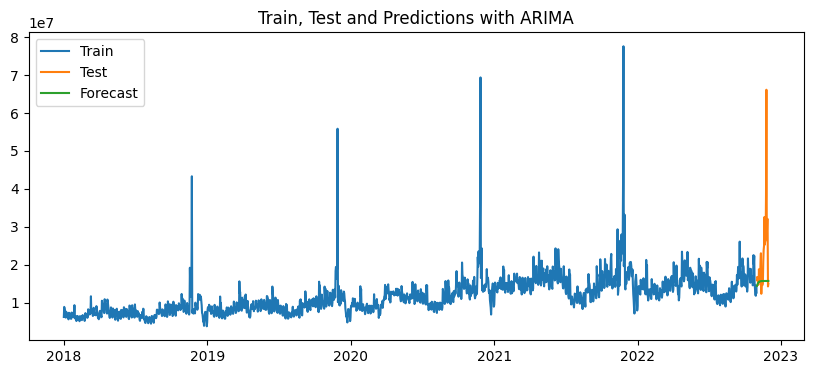

The MAE is  7267306.02
The RMSE is  12366038.30
The MAPE is 24.15 %


In [26]:
# model_assessment(train['y']['2022':],test['y'],predictions_arima,"ARIMA")
model_assessment(train['y'],test['y'],predictions_arima,"ARIMA")

- AIC - Akaike Information Criterion
- BIC - Bayseian Information Criterion
- SARIMA - Seasonal AUto Regressive Integrated Moving Average

SARIMA(p,d,q)(P,D,Q)m 
- p,d,q = non-seasonal components
- P,D,Q = seasonal components

> p = seasonal autoregressive order
> D = seasonal differencing order
> Q = seasonal moving average order
> M = number of periods in each season

How SARIMA Works ?
- seasonal differencing (D) : Stabilize seasonal patternss in the data.
- seasonal Auto-Regression (P) : looking at past seasonal data to forecast future sales.
- seasonla moving Average (Q) : looks into the past errors.

### SARIMA

In [27]:
## Using pmdarima for the arima model and best parameters
model_sarima = auto_arima(train['y'])
model_sarima.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 1765
Model:               SARIMAX(5, 1, 2)   Log Likelihood              -28817.267
Date:                Wed, 10 Dec 2025   AIC                          57650.535
Time:                        09:58:33   BIC                          57694.337
Sample:                    01-01-2018   HQIC                         57666.720
                         - 10-31-2022                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4136      0.120     -3.449      0.001      -0.649      -0.179
ar.L2          0.3017      0.053      5.671      0.000       0.197       0.406
ar.L3          0.1570      0.028      5.705      0.000       0.103       0.211
ar.L4          0.0679      0.029      2.365      0.018       0.012       0.124
ar.L5          0.0466      0.024      1.937      0.053      -0.001       0.094
ma.L1         -0.1598      0.118     -1.354      0.176      -0.391       0.071
ma.L2         -0.7423      0.108     -6.872      0.000      -0.954      -0.531
sigma2      9.084e+12   1.86e-14   4.88e+26      0.000    9.08e+12    9.08e+12
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):            580903.26
Prob(Q):                              0.97   Prob(JB):                         0.00
Heteroskedasticity (H):               3.04   Skew:                             5.15
Prob(H) (two-sided):                  0.00   Kurtosis:                        91.30
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 1.23e+42. Standard errors may be unstable.
"""

In [28]:
## Predictions
predictions_sarima = model_sarima.predict(n_periods = (len(test)))
predictions_sarima

2022-11-01    1.445299e+07
2022-11-02    1.474103e+07
2022-11-03    1.503283e+07
2022-11-04    1.527520e+07
2022-11-05    1.534078e+07
2022-11-06    1.553442e+07
2022-11-07    1.554542e+07
2022-11-08    1.563967e+07
2022-11-09    1.565016e+07
2022-11-10    1.569221e+07
2022-11-11    1.570256e+07
2022-11-12    1.571953e+07
2022-11-13    1.572734e+07
2022-11-14    1.573420e+07
2022-11-15    1.573904e+07
2022-11-16    1.574197e+07
2022-11-17    1.574462e+07
2022-11-18    1.574600e+07
2022-11-19    1.574734e+07
2022-11-20    1.574804e+07
2022-11-21    1.574869e+07
2022-11-22    1.574906e+07
2022-11-23    1.574937e+07
2022-11-24    1.574956e+07
2022-11-25    1.574971e+07
2022-11-26    1.574981e+07
2022-11-27    1.574988e+07
2022-11-28    1.574994e+07
2022-11-29    1.574997e+07
2022-11-30    1.575000e+07
Freq: D, dtype: float64

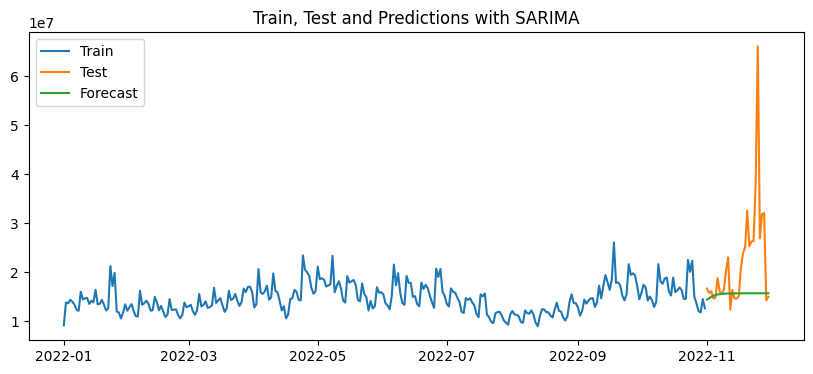

The MAE is  7267306.02
The RMSE is  12366038.30
The MAPE is 24.15 %


In [29]:
model_assessment(train['y']['2022':],test['y'],predictions_sarima,"SARIMA")
#model_assessment(train['y'],test['y'],predictions_arima,"ARIMA")

### SARIMAX
Seasonal Auto Regreesive Integrated Moving Average Ogenous Variables

X - factor = exteranl to time series to enchance prediction efficiency
pros - Increased accuracy, Greater Insight
cons - Complexity , Data Availabilty

In [30]:
## SARIMAX
df.columns
df['discount_rate'] = df['discount_rate'].str.replace("%","").astype(float)
df['coupon_rate'] = df['coupon_rate'].str.replace("%","").astype(float)

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1795 entries, 2018-01-01 to 2022-11-30
Freq: D
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   y              1795 non-null   float64
 1   discount_rate  1795 non-null   float64
 2   coupon_rate    1795 non-null   float64
 3   y_diff         1794 non-null   float64
dtypes: float64(4)
memory usage: 70.1 KB


In [32]:
test_days = 30
exog_train, exog_test = df.iloc[:-test_days,1:3], df.iloc[-test_days:,1:3]
exog_test.head()

,discount_rate,coupon_rate
date,,
2022-11-01,23.85,1.50
2022-11-02,20.76,0.94
2022-11-03,21.85,0.92
2022-11-04,20.17,0.88
2022-11-05,17.85,0.41


In [33]:
# Correct split: Create the target (y) and exogenous variables (exog)
train = df.iloc[:-test_days]  # All data except last 30 rows
test = df.iloc[-test_days:]   # Last 30 rows for testing

# Target variable (y)
y_train = train['y']  # Your target variable from the original df

# Exogenous variables (discount_rate, coupon_rate)
exog_train = train[['discount_rate', 'coupon_rate']]  # Exogenous predictors for training

# Fit the SARIMAX model
from pmdarima import auto_arima

model_sarimax = auto_arima(
    y=y_train,               # Target variable
    exogenous=exog_train,    # Exogenous variables (discount_rate, coupon_rate)
    seasonal=True,
    m=7,                     # Weekly seasonality (if applicable)
    stepwise=True ,  
    maxiter=100,             # Limit the number of iterations for faster fitting
    trace=True         # Stepwise search for hyperparameters
)

model_sarimax.summary()


Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[7] intercept   : AIC=57566.715, Time=3.45 sec
 ARIMA(0,1,0)(0,0,0)[7] intercept   : AIC=58227.547, Time=0.04 sec
 ARIMA(1,1,0)(1,0,0)[7] intercept   : AIC=57935.847, Time=0.22 sec
 ARIMA(0,1,1)(0,0,1)[7] intercept   : AIC=57734.264, Time=0.31 sec
 ARIMA(0,1,0)(0,0,0)[7]             : AIC=58225.549, Time=0.03 sec
 ARIMA(2,1,2)(0,0,1)[7] intercept   : AIC=57640.319, Time=1.82 sec
 ARIMA(2,1,2)(1,0,0)[7] intercept   : AIC=57635.054, Time=1.53 sec
 ARIMA(2,1,2)(2,0,1)[7] intercept   : AIC=57568.136, Time=5.42 sec
 ARIMA(2,1,2)(1,0,2)[7] intercept   : AIC=57568.601, Time=5.79 sec
 ARIMA(2,1,2)(0,0,0)[7] intercept   : AIC=57667.033, Time=0.89 sec
 ARIMA(2,1,2)(0,0,2)[7] intercept   : AIC=57634.563, Time=3.00 sec
 ARIMA(2,1,2)(2,0,0)[7] intercept   : AIC=57627.527, Time=3.07 sec
 ARIMA(2,1,2)(2,0,2)[7] intercept   : AIC=inf, Time=5.97 sec
 ARIMA(1,1,2)(1,0,1)[7] intercept   : AIC=57566.982, Time=1.76 sec
 ARIMA(2,1,1)(1,0,1)[7] i

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                     
=========================================================================================
Dep. Variable:                                 y   No. Observations:                 1765
Model:             SARIMAX(3, 1, 2)x(2, 0, 2, 7)   Log Likelihood              -28762.051
Date:                           Wed, 10 Dec 2025   AIC                          57546.103
Time:                                   10:03:47   BIC                          57606.331
Sample:                               01-01-2018   HQIC                         57568.358
                                    - 10-31-2022                                         
Covariance Type:                             opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept   1.007e+04   4682.761      2.150      0.032     890.275    1.92e+04
ar.L1         -0.3476      0.072     -4.797      0.000      -0.490      -0.206
ar.L2          0.1856      0.032      5.722      0.000       0.122       0.249
ar.L3          0.1034      0.016      6.523      0.000       0.072       0.135
ma.L1         -0.1958      0.074     -2.656      0.008      -0.340      -0.051
ma.L2         -0.5684      0.060     -9.400      0.000      -0.687      -0.450
ar.S.L7        0.0805      0.181      0.445      0.656      -0.274       0.435
ar.S.L14       0.8713      0.172      5.071      0.000       0.534       1.208
ma.S.L7       -0.0035      0.176     -0.020      0.984      -0.349       0.342
ma.S.L14      -0.8322      0.157     -5.310      0.000      -1.139      -0.525
sigma2      9.294e+12      0.000   8.85e+16      0.000    9.29e+12    9.29e+12
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):            848655.01
Prob(Q):                              0.90   Prob(JB):                         0.00
Heteroskedasticity (H):               2.85   Skew:                             5.24
Prob(H) (two-sided):                  0.00   Kurtosis:                       109.94
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 6.07e+30. Standard errors may be unstable.
"""

In [34]:
predictions_sarimax = model_sarimax.predict(n_periods= len(test),x=exog_test)
predictions_sarimax

2022-11-01    1.513411e+07
2022-11-02    1.504534e+07
2022-11-03    1.464457e+07
2022-11-04    1.382187e+07
2022-11-05    1.398001e+07
2022-11-06    1.697855e+07
2022-11-07    1.583308e+07
2022-11-08    1.605211e+07
2022-11-09    1.575797e+07
2022-11-10    1.523585e+07
2022-11-11    1.428027e+07
2022-11-12    1.448986e+07
2022-11-13    1.761291e+07
2022-11-14    1.658423e+07
2022-11-15    1.682759e+07
2022-11-16    1.635487e+07
2022-11-17    1.582120e+07
2022-11-18    1.482105e+07
2022-11-19    1.499263e+07
2022-11-20    1.780770e+07
2022-11-21    1.673572e+07
2022-11-22    1.694582e+07
2022-11-23    1.665825e+07
2022-11-24    1.616896e+07
2022-11-25    1.526419e+07
2022-11-26    1.547008e+07
2022-11-27    1.842691e+07
2022-11-28    1.745385e+07
2022-11-29    1.769225e+07
2022-11-30    1.726673e+07
Freq: D, dtype: float64

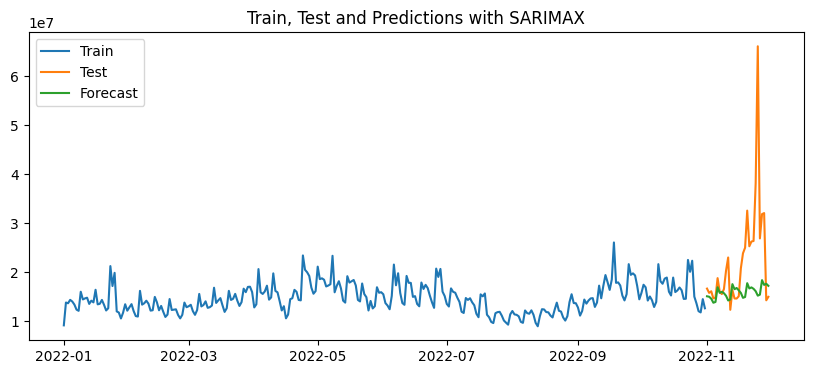

The MAE is  7210543.98
The RMSE is  12152386.47
The MAPE is 24.54 %


In [36]:
model_assessment(train['y']['2022':],test['y'],predictions_sarimax,"SARIMAX")

#### CROSS VALIDATION FOR TIME SERIES
Cross validation means trying the model several times, in different testing situations or in different seasonal periods.There are 2 types of cross-validation
1. Rolling Forecast (Rolling Cross Validation): In this method, the test data from a previous period is continually added to the training data before making the subsequent test run. This continuously extends the size of the training set. A preference is noted for the rolling forecast approach because if data is valuable for model assessment, it should also be valuable for future forecasting. IN SIMPLE = ROLLING EXTENDS THE TRAINING DATA

2. Sliding Forecast (Trimming): This method involves absorbing the test data for the next run but discarding the same amount of data from the most distant past. This technique ensures that the length of the training data remains consistent as the testing window slides forward in time. IN SIMPLE = SLIDING KEEPS THE SAME TRAINING LENGTH

If the data is not used in the final model, it should be used for validation.

In [38]:
## Cross validation
model_cv = ARIMA(order=(2,1,2), seasonal_order=(2,0,2,7))
model_cv

,order,"(2, ...)"
,seasonal_order,"(2, ...)"
,start_params,None
,method,'lbfgs'
,maxiter,50
,suppress_warnings,False
,out_of_sample_size,0
,scoring,'mse'
,scoring_args,None
,trend,None
,with_intercept,True


In [41]:
cv = model_selection.RollingForecastCV(h=30,step=15,initial=df.shape[0]-180)
cv

,h,30
,step,15
,initial,1615


In [ ]:
cv_score = model_selection.cross_val_score(model_cv, y = df['y'], X = df.iloc[:,1:3], scoring=mean_squared_error, cv = cv , verbose=1, error_score=100000000)
cv_score

array([5.96357472e+12, 7.10632055e+12, 7.73832220e+12, 1.60228336e+12,
       1.99706187e+12, 1.09563956e+13, 2.46569210e+13, 1.25766238e+13,
       9.00922797e+12, 5.82536355e+12, 1.19205637e+14])

In [ ]:
## cv performance
rmse = np.sqrt(np.average(cv_score))
print(f"The RMSE is {int(rmse)}")

The RMSE is 4334195


Tuning models allows tailoring the model to your problem and optimizes accuracy

##### Parameter Tuning

In [50]:
## Defining the parameter
param_grid = {'p': [1,2,3],
              'd': [0,1],
              'q': [1,2,3],
              'P': [1,2],
              'D': [0],
              'Q': [1,2]}
grid = ParameterGrid(param_grid)
list(grid)

[{'D': 0, 'P': 1, 'Q': 1, 'd': 0, 'p': 1, 'q': 1},
 {'D': 0, 'P': 1, 'Q': 1, 'd': 0, 'p': 1, 'q': 2},
 {'D': 0, 'P': 1, 'Q': 1, 'd': 0, 'p': 1, 'q': 3},
 {'D': 0, 'P': 1, 'Q': 1, 'd': 0, 'p': 2, 'q': 1},
 {'D': 0, 'P': 1, 'Q': 1, 'd': 0, 'p': 2, 'q': 2},
 {'D': 0, 'P': 1, 'Q': 1, 'd': 0, 'p': 2, 'q': 3},
 {'D': 0, 'P': 1, 'Q': 1, 'd': 0, 'p': 3, 'q': 1},
 {'D': 0, 'P': 1, 'Q': 1, 'd': 0, 'p': 3, 'q': 2},
 {'D': 0, 'P': 1, 'Q': 1, 'd': 0, 'p': 3, 'q': 3},
 {'D': 0, 'P': 1, 'Q': 1, 'd': 1, 'p': 1, 'q': 1},
 {'D': 0, 'P': 1, 'Q': 1, 'd': 1, 'p': 1, 'q': 2},
 {'D': 0, 'P': 1, 'Q': 1, 'd': 1, 'p': 1, 'q': 3},
 {'D': 0, 'P': 1, 'Q': 1, 'd': 1, 'p': 2, 'q': 1},
 {'D': 0, 'P': 1, 'Q': 1, 'd': 1, 'p': 2, 'q': 2},
 {'D': 0, 'P': 1, 'Q': 1, 'd': 1, 'p': 2, 'q': 3},
 {'D': 0, 'P': 1, 'Q': 1, 'd': 1, 'p': 3, 'q': 1},
 {'D': 0, 'P': 1, 'Q': 1, 'd': 1, 'p': 3, 'q': 2},
 {'D': 0, 'P': 1, 'Q': 1, 'd': 1, 'p': 3, 'q': 3},
 {'D': 0, 'P': 1, 'Q': 2, 'd': 0, 'p': 1, 'q': 1},
 {'D': 0, 'P': 1, 'Q': 2, 'd': 

In [52]:
len(list(grid))

72

In [66]:
from sklearn.metrics import make_scorer, mean_squared_error
import numpy as np

rmse_list = []
for params in grid:
    # 1. FIXED: Add endog + exog
    model = ARIMA(endog=df['y'], exog=df.iloc[:,1:3],
                  order=(params['p'], params['d'], params['q']),
                  seasonal_order=(params['P'], params['D'], params['Q'], 7))
    
    # 2. Fit model
    fitted = model.fit()
    
    # 3. Simple rolling test (last 180 points)
    test_start = len(df) - 180
    y_test = df['y'].iloc[test_start:]
    y_pred = fitted.forecast(steps=180, exog=df.iloc[test_start:,1:3])
    
    # 4. Calculate RMSE
    rmse = np.sqrt(np.mean((y_test - y_pred)**2))
    rmse_list.append(rmse)
    print(f"Params {params}: RMSE={rmse:.4f}")


Params {'D': 0, 'P': 0, 'Q': 0, 'd': 0, 'p': 0, 'q': 0}: RMSE=nan
Params {'D': 0, 'P': 0, 'Q': 0, 'd': 0, 'p': 0, 'q': 1}: RMSE=nan
Params {'D': 0, 'P': 0, 'Q': 0, 'd': 0, 'p': 0, 'q': 2}: RMSE=nan
Params {'D': 0, 'P': 0, 'Q': 0, 'd': 0, 'p': 1, 'q': 0}: RMSE=nan
Params {'D': 0, 'P': 0, 'Q': 0, 'd': 0, 'p': 1, 'q': 1}: RMSE=nan
Params {'D': 0, 'P': 0, 'Q': 0, 'd': 0, 'p': 1, 'q': 2}: RMSE=nan
Params {'D': 0, 'P': 0, 'Q': 0, 'd': 0, 'p': 2, 'q': 0}: RMSE=nan
Params {'D': 0, 'P': 0, 'Q': 0, 'd': 0, 'p': 2, 'q': 1}: RMSE=nan
Params {'D': 0, 'P': 0, 'Q': 0, 'd': 0, 'p': 2, 'q': 2}: RMSE=nan
Params {'D': 0, 'P': 0, 'Q': 0, 'd': 1, 'p': 0, 'q': 0}: RMSE=nan
Params {'D': 0, 'P': 0, 'Q': 0, 'd': 1, 'p': 0, 'q': 1}: RMSE=nan
Params {'D': 0, 'P': 0, 'Q': 0, 'd': 1, 'p': 0, 'q': 2}: RMSE=nan
Params {'D': 0, 'P': 0, 'Q': 0, 'd': 1, 'p': 1, 'q': 0}: RMSE=nan
Params {'D': 0, 'P': 0, 'Q': 0, 'd': 1, 'p': 1, 'q': 1}: RMSE=nan
Params {'D': 0, 'P': 0, 'Q': 0, 'd': 1, 'p': 1, 'q': 2}: RMSE=nan
Params {'D

In [67]:
# Create a DataFrame to store the tuning results with parameters and corresponding RMSE values
tuning_results = pd.DataFrame(grid)

# Add the RMSE values calculated during parameter tuning to the DataFrame
tuning_results['rmse'] = rmse_list

tuning_results

,D,P,Q,d,p,q,rmse
0,0,0,0,0,0,0,NaN
1,0,0,0,0,0,1,NaN
2,0,0,0,0,0,2,NaN
3,0,0,0,0,1,0,NaN
4,0,0,0,0,1,1,NaN
...,...,...,...,...,...,...,...
139,1,1,1,1,1,1,NaN
140,1,1,1,1,1,2,NaN
141,1,1,1,1,2,0,NaN
142,1,1,1,1,2,1,NaN


In [72]:
# Save the best parameters
best_idx = tuning_results['rmse'].idxmin()   # get index of best row
best_params = tuning_results.loc[best_idx]

KeyError: nan

#### Predicting the Future

In [70]:
# target variable - daily revenue
y = df['y']
# exogenous variables
X = df.iloc[:,1:3]

In [71]:
# Fetch the best parameters
p = int(best_params.loc['p'])
d = int(best_params.loc['d'])
q = int(best_params.loc['q'])
P = int(best_params.loc['P'])
D = int(best_params.loc['D'])
Q = int(best_params.loc['Q'])

TypeError: cannot convert the series to <class 'int'>